# Configuración de directorios

In [25]:
import os

# Directorios organizados
BASE_DIR = "Images"
UNENCRYPTED_DIR = os.path.join(BASE_DIR, "unencrypted")
ENCRYPTED_DIR = os.path.join(BASE_DIR, "encrypted")
DECRYPTED_DIR = os.path.join(BASE_DIR, "decrypted")

# Crear los directorios si no existen
os.makedirs(UNENCRYPTED_DIR, exist_ok=True)
os.makedirs(ENCRYPTED_DIR, exist_ok=True)
os.makedirs(DECRYPTED_DIR, exist_ok=True)

print("Directorios creados/verificados correctamente.")

Directorios creados/verificados correctamente.


# Cargar y Mostrar la Imagen Original

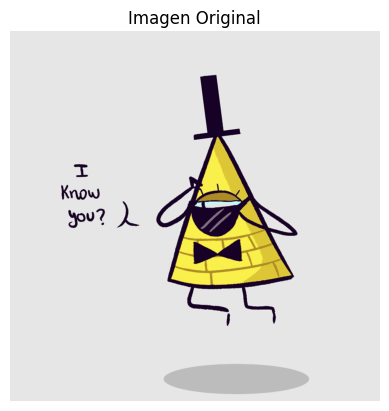

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Cargar la imagen
image_path = os.path.join(UNENCRYPTED_DIR, "pic.png")
img = Image.open(image_path)

# Mostrar la imagen original
plt.imshow(img)
plt.title("Imagen Original")
plt.axis("off")
plt.show()

# Convertir la Imagen a Bytes

In [29]:
import io

# Convertir imagen a bytes
def image_to_bytes(image_path):
    with open(image_path, "rb") as img_file:
        return img_file.read()

# Guardar la imagen en bytes
img_bytes = image_to_bytes(image_path)

print(f"Imagen convertida a {len(img_bytes)} bytes.")

Imagen convertida a 16113 bytes.


# Generación de Clave AES y IV

In [30]:
import secrets
from Crypto.Cipher import AES

def generate_aes_key():
    """Genera una clave aleatoria de 256 bits (32 bytes) para AES."""
    return secrets.token_bytes(32)  # AES-256 usa una clave de 32 bytes

def generate_iv():
    """Genera un IV aleatorio de 16 bytes (128 bits) para AES-CBC."""
    return secrets.token_bytes(16)

# Generamos clave y IV
key = generate_aes_key()
iv = generate_iv()

print(f"Clave AES generada (hex): {key.hex()}")
print(f"IV AES generado (hex): {iv.hex()}")

Clave AES generada (hex): e521be76fb1c9d570aef90bb489bfc87eba6367450d34cf3807984e19b90b78d
IV AES generado (hex): d3459e74798c520a985ea788358cd685


# Cifrado AES en ECB

In [31]:
from Crypto.Util.Padding import pad, unpad

def encrypt_aes_ecb(data, key):
    """Cifra los datos usando AES en modo ECB."""
    cipher = AES.new(key, AES.MODE_ECB)
    encrypted_data = cipher.encrypt(pad(data, AES.block_size))  # Aplica padding automático
    return encrypted_data

# Cifrar la imagen en ECB
encrypted_ecb = encrypt_aes_ecb(img_bytes, key)

print(f"Imagen cifrada con ECB (tamaño): {len(encrypted_ecb)} bytes.")

Imagen cifrada con ECB (tamaño): 16128 bytes.


# Cifrado AES en CBC

In [32]:
def encrypt_aes_cbc(data, key, iv):
    """Cifra los datos usando AES en modo CBC."""
    cipher = AES.new(key, AES.MODE_CBC, iv)
    encrypted_data = cipher.encrypt(pad(data, AES.block_size))
    return encrypted_data

# Cifrar la imagen en CBC
encrypted_cbc = encrypt_aes_cbc(img_bytes, key, iv)

print(f"Imagen cifrada con CBC (tamaño): {len(encrypted_cbc)} bytes.")

Imagen cifrada con CBC (tamaño): 16128 bytes.


# Función para Guardar Datos Cifrados

In [33]:
def save_encrypted_image(encrypted_data, filename):
    """Guarda los datos cifrados en la carpeta ENCRYPTED."""
    path = os.path.join(ENCRYPTED_DIR, filename)
    with open(path, "wb") as file:
        file.write(encrypted_data)
    print(f"Imagen cifrada guardada en: {path}")

# Guardar imágenes cifradas
save_encrypted_image(encrypted_ecb, "encrypted_ecb.png")
save_encrypted_image(encrypted_cbc, "encrypted_cbc.png")

Imagen cifrada guardada en: Images/encrypted/encrypted_ecb.png
Imagen cifrada guardada en: Images/encrypted/encrypted_cbc.png


# Función para Guardar Imágenes Descifradas

In [34]:
def save_decrypted_image(decrypted_data, filename):
    """Guarda la imagen descifrada en la carpeta DECRYPTED."""
    try:
        img = Image.open(io.BytesIO(decrypted_data))  # Convertir bytes a imagen
        path = os.path.join(DECRYPTED_DIR, filename)
        img.save(path, format="PNG")  # Guardar en formato PNG
        print(f"Imagen descifrada guardada en: {path}")
    except Exception as e:
        print(f"Error al guardar la imagen descifrada: {e}")

# Descifrado AES en ECB

In [36]:
def decrypt_aes_ecb(encrypted_data, key):
    """Descifra los datos usando AES en modo ECB."""
    cipher = AES.new(key, AES.MODE_ECB)
    decrypted_data = unpad(cipher.decrypt(encrypted_data), AES.block_size)
    return decrypted_data

# Descifrar la imagen en ECB
decrypted_ecb = decrypt_aes_ecb(encrypted_ecb, key)

# Guardar la imagen descifrada
save_decrypted_image(decrypted_ecb, "decrypted_ecb.png")

print("Imagen descifrada correctamente en ECB.")

Imagen descifrada guardada en: Images/decrypted/decrypted_ecb.png
Imagen descifrada correctamente en ECB.


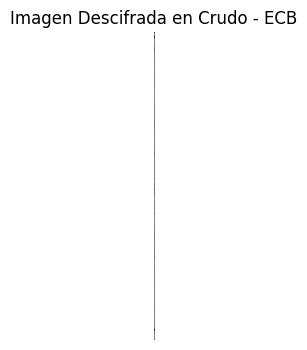

In [39]:
# Mostrar la imagen descifrada en crudo (RAW BYTES) para ECB
raw_ecb_array = np.frombuffer(decrypted_ecb, dtype=np.uint8)

# Redimensionar el array para simular una imagen en crudo
raw_ecb_array = raw_ecb_array[:(raw_ecb_array.size // 3) * 3]  # Asegurar que sea múltiplo de 3 (RGB)
raw_ecb_array = raw_ecb_array.reshape(-1, 3)  # Convertir en matriz RGB

# Mostrar la imagen en crudo descifrada con ECB
plt.figure(figsize=(8, 4))
plt.imshow(raw_ecb_array, cmap="gray")
plt.title("Imagen Descifrada en Crudo - ECB")
plt.axis("off")
plt.show()

# Descifrado AES en CBC

In [37]:
def decrypt_aes_cbc(encrypted_data, key, iv):
    """Descifra los datos usando AES en modo CBC."""
    cipher = AES.new(key, AES.MODE_CBC, iv)
    decrypted_data = unpad(cipher.decrypt(encrypted_data), AES.block_size)
    return decrypted_data

# Descifrar la imagen en CBC
decrypted_cbc = decrypt_aes_cbc(encrypted_cbc, key, iv)

# Guardar la imagen descifrada
save_decrypted_image(decrypted_cbc, "decrypted_cbc.png")

print("Imagen descifrada correctamente en CBC.")

Imagen descifrada guardada en: Images/decrypted/decrypted_cbc.png
Imagen descifrada correctamente en CBC.


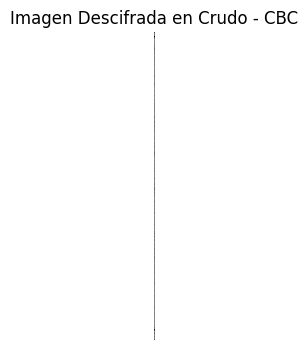

In [40]:
# Mostrar la imagen descifrada en crudo (RAW BYTES) para CBC
raw_cbc_array = np.frombuffer(decrypted_cbc, dtype=np.uint8)

# Redimensionar el array para simular una imagen en crudo
raw_cbc_array = raw_cbc_array[:(raw_cbc_array.size // 3) * 3]  # Asegurar que sea múltiplo de 3 (RGB)
raw_cbc_array = raw_cbc_array.reshape(-1, 3)  # Convertir en matriz RGB

# Mostrar la imagen en crudo descifrada con CBC
plt.figure(figsize=(8, 4))
plt.imshow(raw_cbc_array, cmap="gray")
plt.title("Imagen Descifrada en Crudo - CBC")
plt.axis("off")
plt.show()

# Mostrar las Imágenes Descifradas

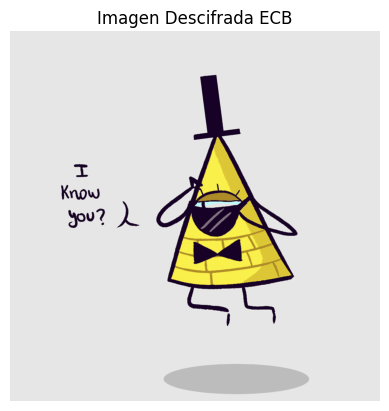

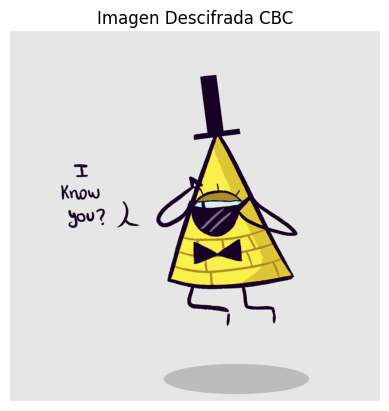

In [38]:
# Cargar y mostrar la imagen descifrada en ECB
img_dec_ecb = Image.open(os.path.join(DECRYPTED_DIR, "decrypted_ecb.png"))
plt.imshow(img_dec_ecb)
plt.title("Imagen Descifrada ECB")
plt.axis("off")
plt.show()

# Cargar y mostrar la imagen descifrada en CBC
img_dec_cbc = Image.open(os.path.join(DECRYPTED_DIR, "decrypted_cbc.png"))
plt.imshow(img_dec_cbc)
plt.title("Imagen Descifrada CBC")
plt.axis("off")
plt.show()